<a href="https://colab.research.google.com/github/haasinisalihundam-netizen/ML_PROJECT_Bankruptcy-Prediction-Using-Decision-Trees-and-Random-Forest-with-Precision-Recall-Analys/blob/main/ML_Bankruptcy_Prediction_EDA_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Taiwanese Bankruptcy Prediction dataset...

Dataset loaded successfully!

DATASET OVERVIEW
Number of companies     : 6819
Number of features      : 95
Total columns           : 96
Target column           : Bankrupt?
Missing values          : 0
Duplicate rows          : 0

DATA QUALITY SUMMARY


,Information,Value
0,Number of Companies,6819
1,Number of Financial Features,95
2,Missing Values,0
3,Duplicate Rows,0
4,Numeric Features,95
5,Non-Numeric Features,0
6,Constant / Redundant Features,1



Constant/redundant feature(s) detected:
 - Net Income Flag

MISSING VALUE ANALYSIS
No missing values are present in the dataset.

DUPLICATE ROW ANALYSIS
No exact duplicate rows are present.

BANKRUPTCY CLASS DISTRIBUTION


,Class,Meaning,Count,Percentage
0,0,Non-Bankrupt,6599,96.77
1,1,Bankrupt,220,3.23



Important observation: The dataset is strongly imbalanced.
Only 3.23% of companies belong to the bankrupt class.

TOP FEATURES ASSOCIATED WITH BANKRUPTCY


,Feature,Correlation,Absolute Correlation
0,Net Income to Total Assets,-0.3155,0.3155
1,ROA(A) before interest and % after tax,-0.2829,0.2829
2,ROA(B) before interest and depreciation after tax,-0.2731,0.2731
3,ROA(C) before interest and depreciation before interest,-0.2608,0.2608
4,Debt ratio %,0.2502,0.2502
5,Net worth/Assets,-0.2502,0.2502
6,Persistent EPS in the Last Four Seasons,-0.2196,0.2196
7,Retained Earnings to Total Assets,-0.2178,0.2178
8,Net profit before tax/Paid-in capital,-0.2079,0.2079
9,Per Share Net profit before tax (Yuan ¥),-0.2014,0.2014



CLASS-WISE COMPARISON OF TOP FINANCIAL INDICATORS


,Feature,Correlation with Bankruptcy,Non-Bankrupt Mean,Bankrupt Mean
0,Net Income to Total Assets,-0.3155,0.8101,0.7381
1,ROA(A) before interest and % after tax,-0.2829,0.5620,0.4569
2,ROA(B) before interest and depreciation after tax,-0.2731,0.5567,0.4615
3,ROA(C) before interest and depreciation before interest,-0.2608,0.5081,0.4185
4,Debt ratio %,0.2502,0.1107,0.1870
5,Net worth/Assets,-0.2502,0.8893,0.8130
6,Persistent EPS in the Last Four Seasons,-0.2196,0.2301,0.1888
7,Retained Earnings to Total Assets,-0.2178,0.9357,0.9042
8,Net profit before tax/Paid-in capital,-0.2079,0.1839,0.1477
9,Per Share Net profit before tax (Yuan ¥),-0.2014,0.1856,0.1478


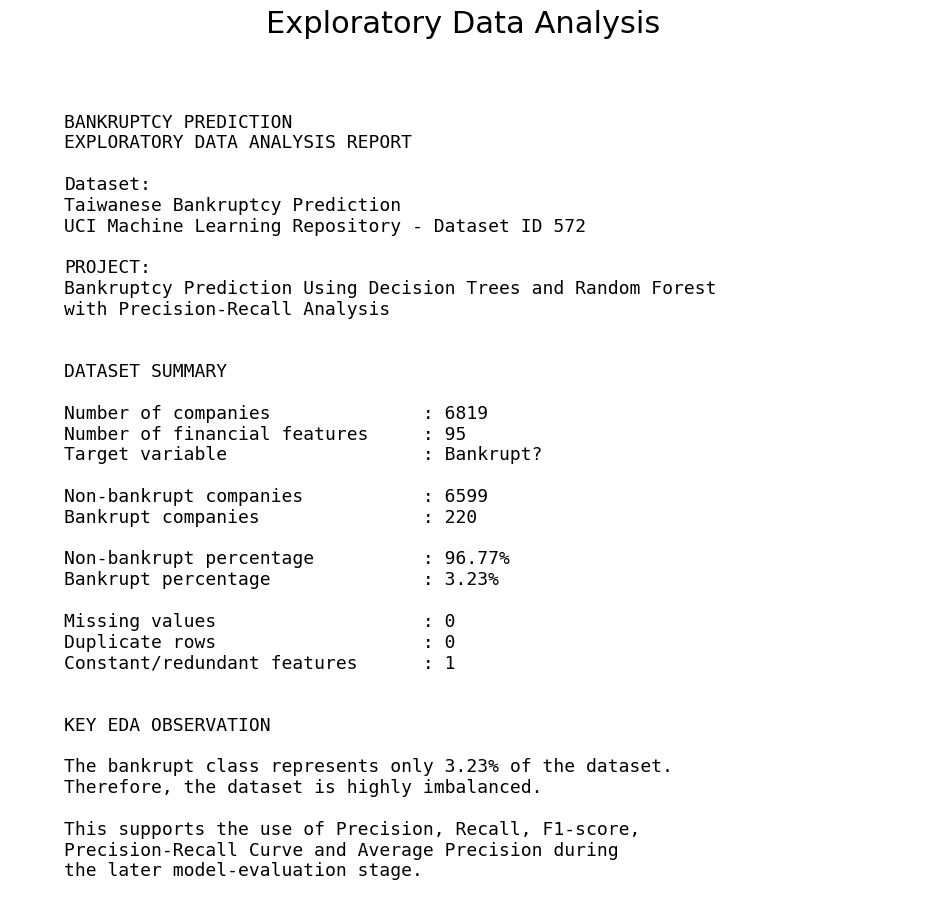

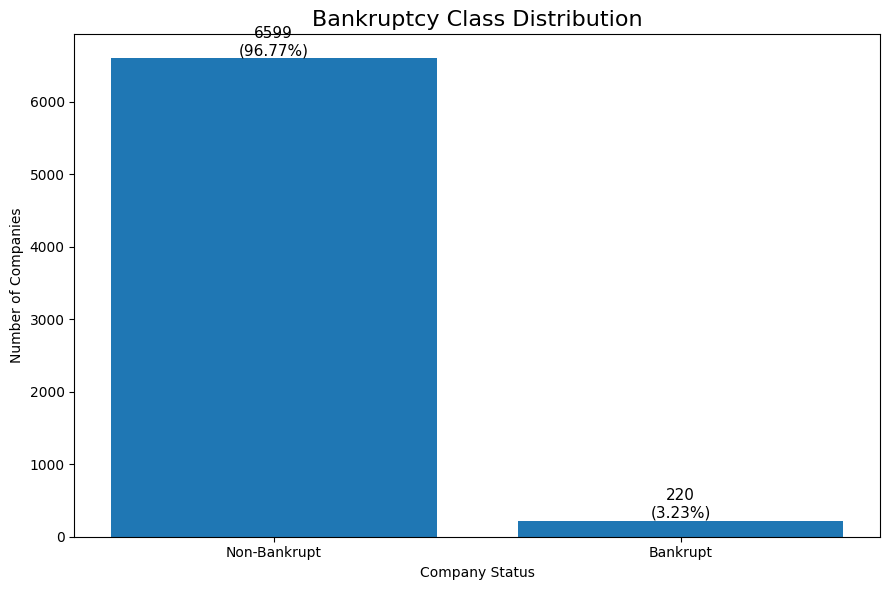

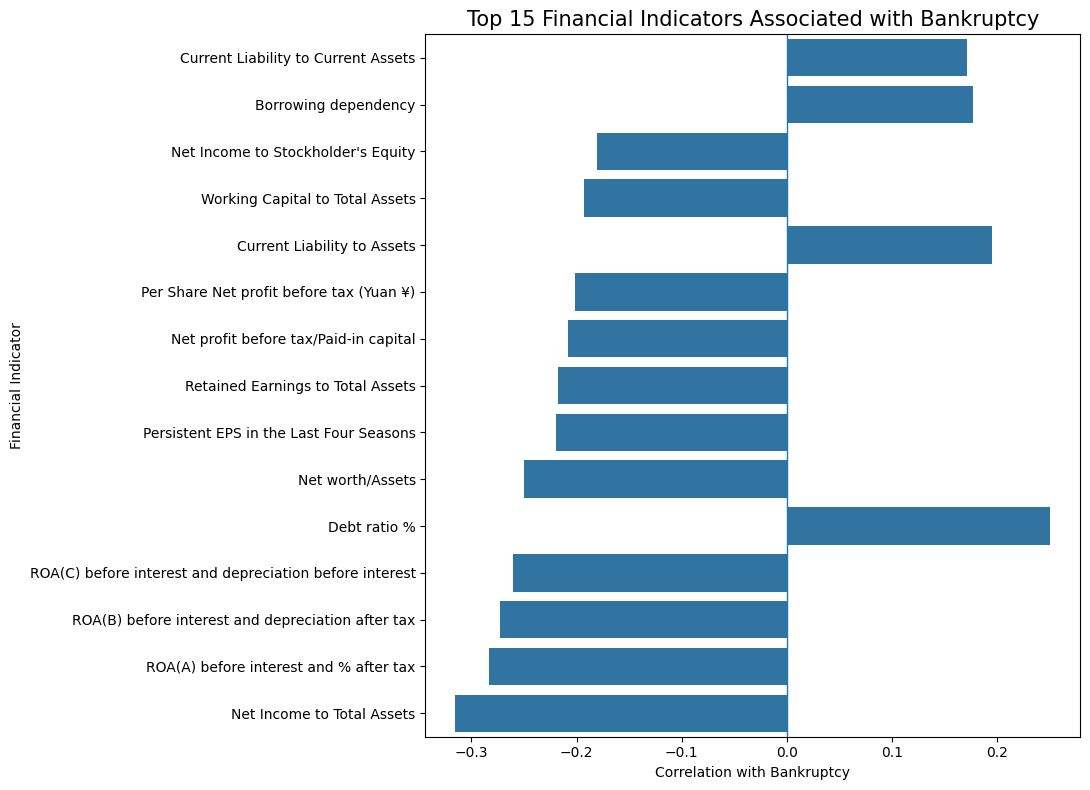

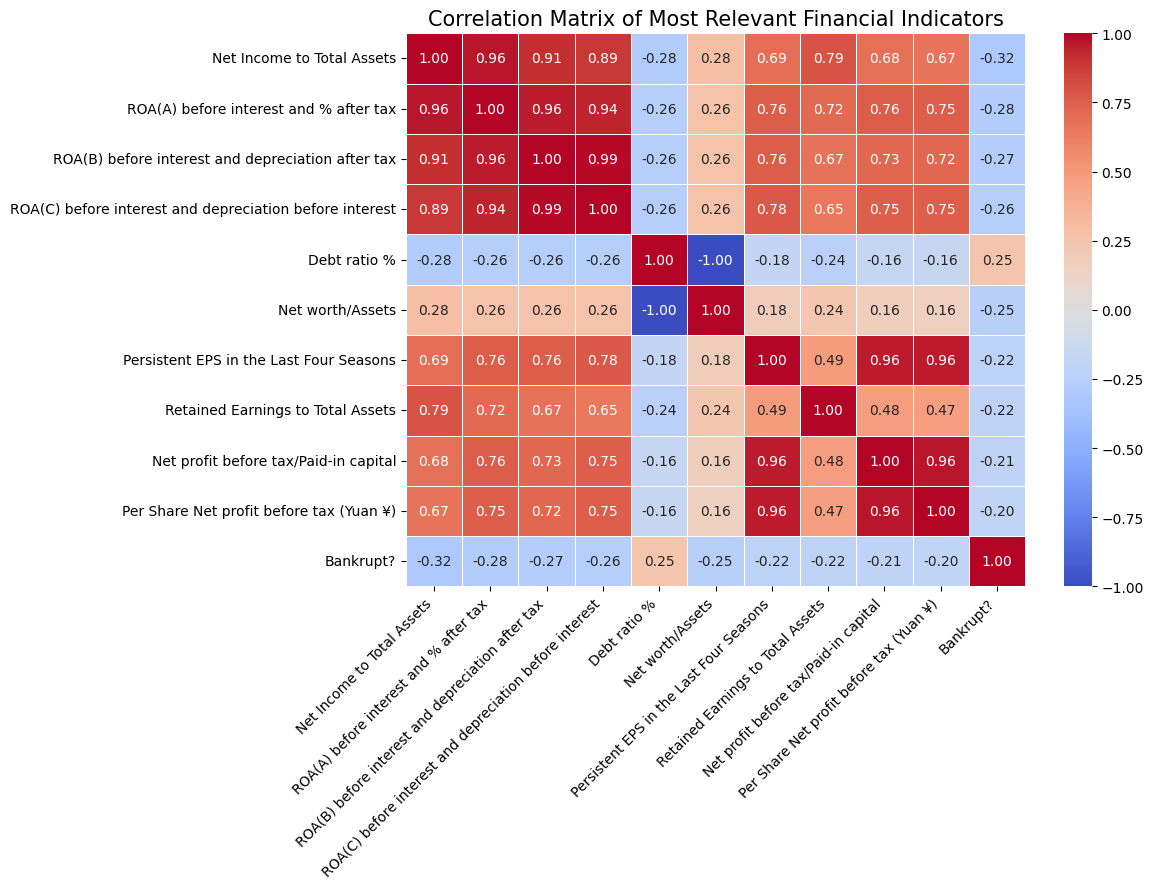

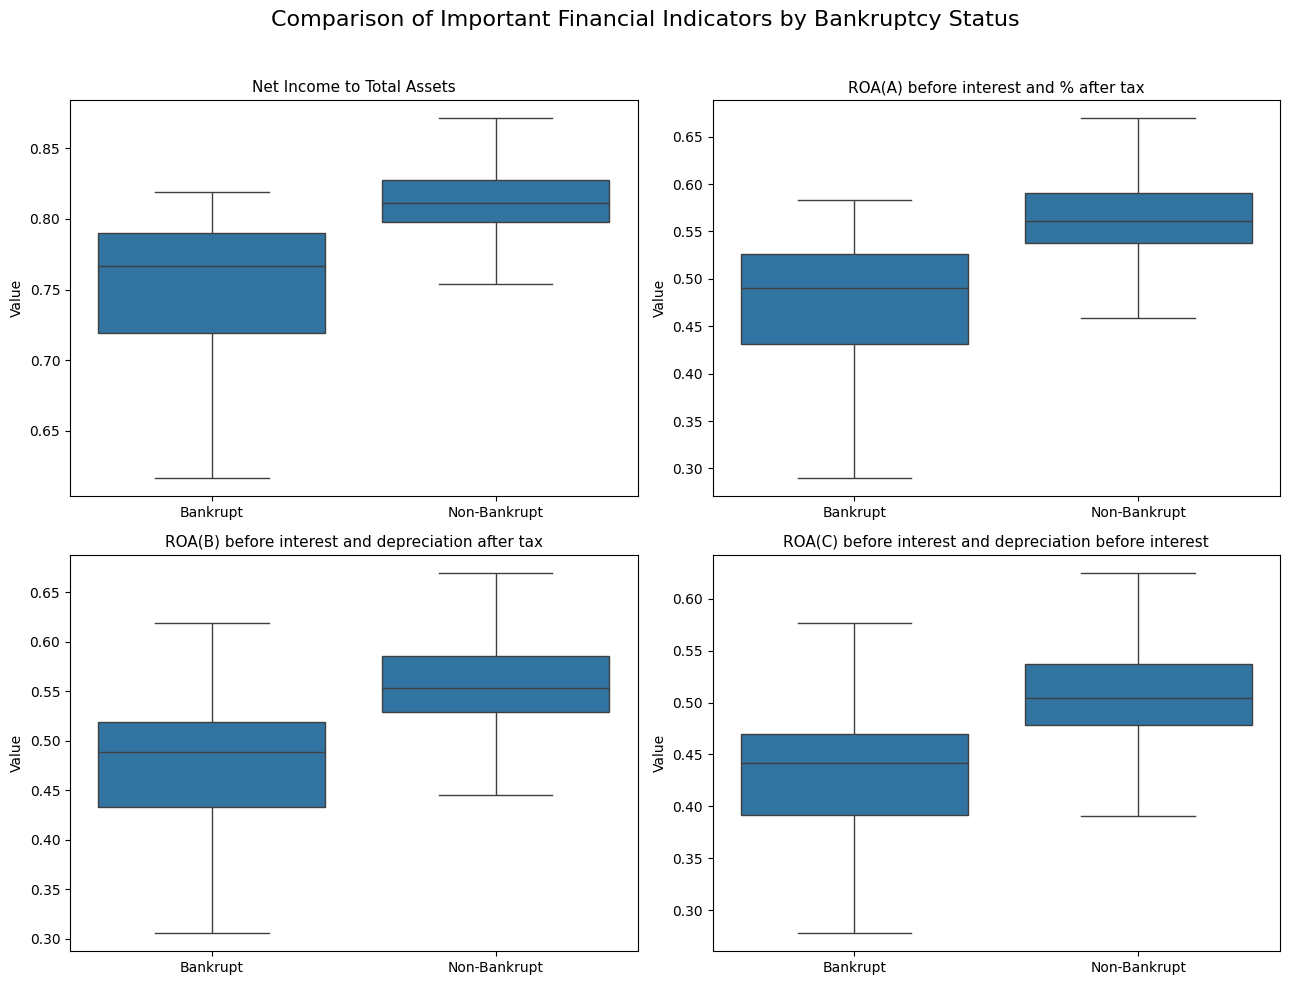

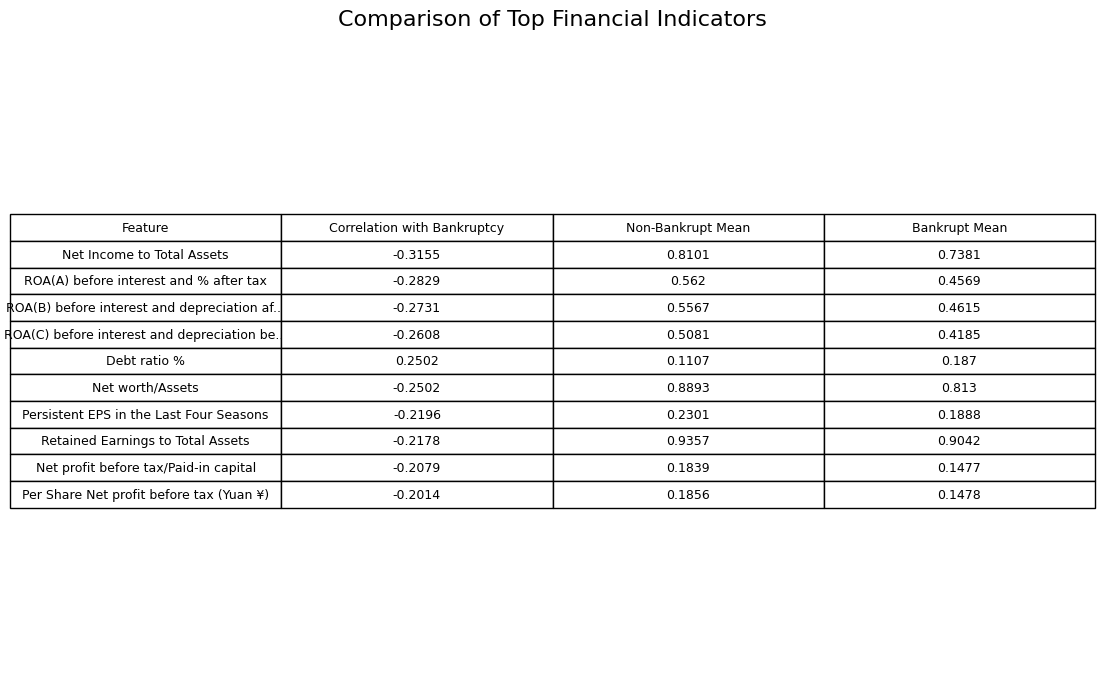



EDA COMPLETED SUCCESSFULLY

Dataset size:
6819 companies

Financial features:
95

Target:
Bankrupt?

Bankrupt companies:
220
(3.23%)

Non-bankrupt companies:
6599
(96.77%)

Missing values:
0

Duplicate rows:
0

Constant/redundant columns:
['Net Income Flag']

EDA report created:
/content/Bankruptcy_EDA_Report.pdf


Top financial indicators identified during EDA:


,Feature,Correlation,Absolute Correlation
0,Net Income to Total Assets,-0.3155,0.3155
1,ROA(A) before interest and % after tax,-0.2829,0.2829
2,ROA(B) before interest and depreciation after tax,-0.2731,0.2731
3,ROA(C) before interest and depreciation before interest,-0.2608,0.2608
4,Debt ratio %,0.2502,0.2502
5,Net worth/Assets,-0.2502,0.2502
6,Persistent EPS in the Last Four Seasons,-0.2196,0.2196
7,Retained Earnings to Total Assets,-0.2178,0.2178
8,Net profit before tax/Paid-in capital,-0.2079,0.2079
9,Per Share Net profit before tax (Yuan ¥),-0.2014,0.2014


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# BANKRUPTCY PREDICTION PROJECT
# Exploratory Data Analysis (EDA)
#
# Dataset:
# UCI Taiwanese Bankruptcy Prediction - Dataset ID 572
#
# Project:
# Bankruptcy Prediction Using Decision Trees and Random Forest
# with Precision-Recall Analysis
# ============================================================


# ============================================================
# 1. INSTALL REQUIRED PACKAGE
# ============================================================

!pip -q install ucimlrepo


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from ucimlrepo import fetch_ucirepo
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


# ============================================================
# 3. LOAD DATASET DIRECTLY FROM UCI
# ============================================================

print("Loading Taiwanese Bankruptcy Prediction dataset...")

dataset = fetch_ucirepo(id=572)

X = dataset.data.features.copy()
y_data = dataset.data.targets.copy()

# Make sure target is a DataFrame
if isinstance(y_data, pd.Series):
    y_data = y_data.to_frame()

# Combine features and target
df = pd.concat([y_data, X], axis=1)

# Remove unwanted spaces present in original column names
df.columns = df.columns.astype(str).str.strip()

TARGET = "Bankrupt?"

if TARGET not in df.columns:
    # In case the UCI target column has a slightly different name
    target_column = y_data.columns[0].strip()
    df.rename(columns={target_column: TARGET}, inplace=True)

# Make target numeric integer
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce").astype(int)

print("\nDataset loaded successfully!")


# ============================================================
# 4. BASIC DATASET INFORMATION
# ============================================================

number_of_rows = df.shape[0]
number_of_columns = df.shape[1]
number_of_features = number_of_columns - 1

missing_values = int(df.isnull().sum().sum())
duplicate_rows = int(df.duplicated().sum())

print("\n" + "=" * 65)
print("DATASET OVERVIEW")
print("=" * 65)

print(f"Number of companies     : {number_of_rows}")
print(f"Number of features      : {number_of_features}")
print(f"Total columns           : {number_of_columns}")
print(f"Target column           : {TARGET}")
print(f"Missing values          : {missing_values}")
print(f"Duplicate rows          : {duplicate_rows}")


# ============================================================
# 5. DATA QUALITY SUMMARY
# ============================================================

X_features = df.drop(columns=[TARGET])

numeric_features = X_features.select_dtypes(include=np.number).columns.tolist()

non_numeric_features = [
    col for col in X_features.columns
    if col not in numeric_features
]

constant_columns = [
    col
    for col in X_features.columns
    if X_features[col].nunique(dropna=False) <= 1
]

quality_summary = pd.DataFrame({
    "Information": [
        "Number of Companies",
        "Number of Financial Features",
        "Missing Values",
        "Duplicate Rows",
        "Numeric Features",
        "Non-Numeric Features",
        "Constant / Redundant Features"
    ],
    "Value": [
        number_of_rows,
        number_of_features,
        missing_values,
        duplicate_rows,
        len(numeric_features),
        len(non_numeric_features),
        len(constant_columns)
    ]
})

print("\nDATA QUALITY SUMMARY")
display(quality_summary)

if constant_columns:
    print("\nConstant/redundant feature(s) detected:")
    for col in constant_columns:
        print(" -", col)
else:
    print("\nNo constant columns detected.")


# ============================================================
# 6. MISSING VALUE CHECK
# ============================================================

missing_by_column = df.isnull().sum()

missing_columns = missing_by_column[missing_by_column > 0]

print("\n" + "=" * 65)
print("MISSING VALUE ANALYSIS")
print("=" * 65)

if len(missing_columns) == 0:
    print("No missing values are present in the dataset.")
else:
    print("Columns containing missing values:")
    display(
        missing_columns
        .sort_values(ascending=False)
        .to_frame("Missing Values")
    )


# ============================================================
# 7. DUPLICATE CHECK
# ============================================================

print("\n" + "=" * 65)
print("DUPLICATE ROW ANALYSIS")
print("=" * 65)

if duplicate_rows == 0:
    print("No exact duplicate rows are present.")
else:
    print(f"{duplicate_rows} duplicate rows were found.")


# ============================================================
# 8. TARGET / CLASS DISTRIBUTION
# ============================================================

class_counts = df[TARGET].value_counts().sort_index()

class_percentages = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index() * 100
)

class_summary = pd.DataFrame({
    "Class": [0, 1],
    "Meaning": ["Non-Bankrupt", "Bankrupt"],
    "Count": [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ],
    "Percentage": [
        class_percentages.get(0, 0),
        class_percentages.get(1, 0)
    ]
})

class_summary["Percentage"] = class_summary["Percentage"].round(2)

print("\n" + "=" * 65)
print("BANKRUPTCY CLASS DISTRIBUTION")
print("=" * 65)

display(class_summary)

bankrupt_percentage = class_percentages.get(1, 0)

if bankrupt_percentage < 20:
    print(
        "\nImportant observation: "
        "The dataset is strongly imbalanced."
    )

    print(
        f"Only {bankrupt_percentage:.2f}% of companies "
        "belong to the bankrupt class."
    )


# ============================================================
# 9. REMOVE CONSTANT FEATURES FOR EDA CALCULATIONS
# ============================================================

# We are NOT permanently deleting columns from the original dataset.
# This copy is only used for meaningful EDA calculations.

X_eda = X_features.drop(
    columns=constant_columns,
    errors="ignore"
)

# Keep only numeric columns for correlation analysis
X_eda = X_eda.select_dtypes(include=np.number)

# Handle infinity if it exists
X_eda = X_eda.replace([np.inf, -np.inf], np.nan)


# ============================================================
# 10. CORRELATION WITH BANKRUPTCY TARGET
# ============================================================

target_correlations = X_eda.apply(
    lambda column: column.corr(df[TARGET])
)

target_correlations = target_correlations.dropna()

absolute_correlations = (
    target_correlations
    .abs()
    .sort_values(ascending=False)
)

TOP_N = 15

top_features = absolute_correlations.head(TOP_N)

top_correlation_table = pd.DataFrame({
    "Feature": top_features.index,
    "Correlation": [
        target_correlations[feature]
        for feature in top_features.index
    ],
    "Absolute Correlation": top_features.values
})

top_correlation_table.reset_index(drop=True, inplace=True)

print("\n" + "=" * 65)
print("TOP FEATURES ASSOCIATED WITH BANKRUPTCY")
print("=" * 65)

display(
    top_correlation_table.style.format({
        "Correlation": "{:.4f}",
        "Absolute Correlation": "{:.4f}"
    })
)


# ============================================================
# 11. CLASS-WISE COMPARISON OF IMPORTANT FEATURES
# ============================================================

top_10_features = top_features.head(10).index.tolist()

class_mean_comparison = (
    df
    .groupby(TARGET)[top_10_features]
    .mean()
    .T
)

class_mean_comparison.columns = [
    "Non-Bankrupt Mean",
    "Bankrupt Mean"
]

class_mean_comparison.insert(
    0,
    "Correlation with Bankruptcy",
    [
        target_correlations[feature]
        for feature in class_mean_comparison.index
    ]
)

class_mean_comparison.insert(
    0,
    "Feature",
    class_mean_comparison.index
)

class_mean_comparison.reset_index(
    drop=True,
    inplace=True
)

print("\n" + "=" * 65)
print("CLASS-WISE COMPARISON OF TOP FINANCIAL INDICATORS")
print("=" * 65)

display(
    class_mean_comparison.style.format({
        "Correlation with Bankruptcy": "{:.4f}",
        "Non-Bankrupt Mean": "{:.4f}",
        "Bankrupt Mean": "{:.4f}"
    })
)


# ============================================================
# 12. SAVE IMPORTANT TABLES AS CSV
# ============================================================

quality_summary.to_csv(
    "/content/EDA_Data_Quality_Summary.csv",
    index=False
)

class_summary.to_csv(
    "/content/EDA_Class_Distribution.csv",
    index=False
)

top_correlation_table.to_csv(
    "/content/EDA_Top_Features.csv",
    index=False
)

class_mean_comparison.to_csv(
    "/content/EDA_Class_Feature_Comparison.csv",
    index=False
)


# ============================================================
# 13. CREATE PDF EDA REPORT
# ============================================================

REPORT_FILE = "/content/Bankruptcy_EDA_Report.pdf"

pdf = PdfPages(REPORT_FILE)


# ============================================================
# REPORT PAGE 1 - SUMMARY
# ============================================================

fig = plt.figure(figsize=(11.7, 8.3))

plt.axis("off")

summary_text = f"""
BANKRUPTCY PREDICTION
EXPLORATORY DATA ANALYSIS REPORT

Dataset:
Taiwanese Bankruptcy Prediction
UCI Machine Learning Repository - Dataset ID 572

PROJECT:
Bankruptcy Prediction Using Decision Trees and Random Forest
with Precision-Recall Analysis


DATASET SUMMARY

Number of companies              : {number_of_rows}
Number of financial features     : {number_of_features}
Target variable                  : {TARGET}

Non-bankrupt companies           : {class_counts.get(0, 0)}
Bankrupt companies               : {class_counts.get(1, 0)}

Non-bankrupt percentage          : {class_percentages.get(0, 0):.2f}%
Bankrupt percentage              : {class_percentages.get(1, 0):.2f}%

Missing values                   : {missing_values}
Duplicate rows                   : {duplicate_rows}
Constant/redundant features      : {len(constant_columns)}


KEY EDA OBSERVATION

The bankrupt class represents only {bankrupt_percentage:.2f}% of the dataset.
Therefore, the dataset is highly imbalanced.

This supports the use of Precision, Recall, F1-score,
Precision-Recall Curve and Average Precision during
the later model-evaluation stage.
"""

plt.text(
    0.06,
    0.95,
    summary_text,
    fontsize=13,
    va="top",
    family="monospace"
)

plt.title(
    "Exploratory Data Analysis",
    fontsize=22,
    pad=20
)

pdf.savefig(fig, bbox_inches="tight")
plt.show()
plt.close(fig)


# ============================================================
# REPORT PAGE 2 - CLASS DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

plot_data = class_summary.copy()

bars = ax.bar(
    plot_data["Meaning"],
    plot_data["Count"]
)

ax.set_title(
    "Bankruptcy Class Distribution",
    fontsize=16
)

ax.set_xlabel("Company Status")
ax.set_ylabel("Number of Companies")

for bar, count, percentage in zip(
    bars,
    plot_data["Count"],
    plot_data["Percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

pdf.savefig(fig, bbox_inches="tight")
plt.show()
plt.close(fig)


# ============================================================
# REPORT PAGE 3 - TOP CORRELATED FEATURES
# ============================================================

correlation_plot = top_correlation_table.copy()

# Reverse order so strongest feature appears at top
correlation_plot = correlation_plot.iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=correlation_plot,
    y="Feature",
    x="Correlation",
    ax=ax
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_title(
    "Top 15 Financial Indicators Associated with Bankruptcy",
    fontsize=15
)

ax.set_xlabel(
    "Correlation with Bankruptcy"
)

ax.set_ylabel(
    "Financial Indicator"
)

plt.tight_layout()

pdf.savefig(fig, bbox_inches="tight")
plt.show()
plt.close(fig)


# ============================================================
# REPORT PAGE 4 - COMPACT CORRELATION HEATMAP
# ============================================================

# Only top features are shown.
# A 96 x 96 heatmap would be unnecessarily large and unreadable.

heatmap_features = top_10_features + [TARGET]

heatmap_data = df[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "Correlation Matrix of Most Relevant Financial Indicators",
    fontsize=15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

pdf.savefig(fig, bbox_inches="tight")
plt.show()
plt.close(fig)


# ============================================================
# REPORT PAGE 5 - TOP FEATURE DISTRIBUTIONS BY CLASS
# ============================================================

top_4_features = top_features.head(4).index.tolist()

plot_df = df.copy()

plot_df["Company Status"] = plot_df[TARGET].map({
    0: "Non-Bankrupt",
    1: "Bankrupt"
})

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10)
)

axes = axes.flatten()

for i, feature in enumerate(top_4_features):

    sns.boxplot(
        data=plot_df,
        x="Company Status",
        y=feature,
        showfliers=False,
        ax=axes[i]
    )

    axes[i].set_title(
        feature,
        fontsize=11
    )

    axes[i].set_xlabel("")

    axes[i].set_ylabel(
        "Value"
    )

fig.suptitle(
    "Comparison of Important Financial Indicators by Bankruptcy Status",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

pdf.savefig(fig, bbox_inches="tight")
plt.show()
plt.close(fig)


# ============================================================
# REPORT PAGE 6 - TOP FEATURE TABLE
# ============================================================

table_for_pdf = class_mean_comparison.copy().head(10)

# Shorten names only inside PDF so the table fits.
# Original full names remain in the CSV file.

def shorten_name(text, length=42):
    text = str(text)

    if len(text) <= length:
        return text

    return text[:length] + "..."


table_for_pdf["Feature"] = (
    table_for_pdf["Feature"]
    .apply(shorten_name)
)

for column in [
    "Correlation with Bankruptcy",
    "Non-Bankrupt Mean",
    "Bankrupt Mean"
]:
    table_for_pdf[column] = (
        table_for_pdf[column]
        .astype(float)
        .round(4)
    )


fig, ax = plt.subplots(
    figsize=(14, 8)
)

ax.axis("off")

table = ax.table(
    cellText=table_for_pdf.values,
    colLabels=table_for_pdf.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

ax.set_title(
    "Comparison of Top Financial Indicators",
    fontsize=16,
    pad=20
)

pdf.savefig(
    fig,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# FINISH PDF
# ============================================================

pdf.close()


# ============================================================
# 14. FINAL EDA SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"""
Dataset size:
{number_of_rows} companies

Financial features:
{number_of_features}

Target:
{TARGET}

Bankrupt companies:
{class_counts.get(1, 0)}
({class_percentages.get(1, 0):.2f}%)

Non-bankrupt companies:
{class_counts.get(0, 0)}
({class_percentages.get(0, 0):.2f}%)

Missing values:
{missing_values}

Duplicate rows:
{duplicate_rows}

Constant/redundant columns:
{constant_columns if constant_columns else "None"}

EDA report created:
{REPORT_FILE}
""")


# ============================================================
# 15. DISPLAY TOP FEATURES ONE LAST TIME
# ============================================================

print("\nTop financial indicators identified during EDA:")

display(
    top_correlation_table.style.format({
        "Correlation": "{:.4f}",
        "Absolute Correlation": "{:.4f}"
    })
)


# ============================================================
# 16. DOWNLOAD PDF REPORT
# ============================================================

print("\nDownloading EDA report...")

files.download(REPORT_FILE)